# 10 — Noise ceiling: how close do the models get?

Every pKi is a lab measurement, and repeat measurements of the same molecule disagree. A model that knew every molecule's *true* affinity would still look wrong by that measurement noise, so the noise sets a floor under the RMSE any model can reliably reach.

This notebook uses a published rough estimate of that noise rather than measuring it here. Kramer et al. studied repeat measurements across ChEMBL and report a standard deviation of about **0.54 pKi** for public K<sub>i</sub> values (*The experimental uncertainty of heterogeneous public K<sub>i</sub> data*, J. Med. Chem. 2012, 55, 5165–5173, [PubMed 22643060](https://pubmed.ncbi.nlm.nih.gov/22643060/)). It is a ChEMBL-wide average, not specific to CB2, so treat the floor as approximate.

It trains nothing and only reads the saved validation predictions. The figure is saved to `results/noise_ceiling.png`.

In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from build_project_reference import pipeline_state, latest_models, comparison_rows

NOISE_FLOOR = 0.54   # Published SD of public ChEMBL Ki values, in pKi (Kramer et al. 2012).

# The project's current validation scores: latest baseline and tuned run of each model
# (MLP scores are means over its five seeds).
state, status = pipeline_state()
scores = pd.DataFrame(comparison_rows(latest_models(state, status)))

def validation_errors(row):
    """Squared validation errors: one row per molecule, one column per seed."""
    frame = pd.read_csv(project_root / Path(row["source_metrics"]).with_name("predictions.csv"))
    frame = frame[(frame["split_strategy"] == row["split_strategy"]) & (frame["subset"] == "validation")]
    if row["model"].startswith("Dummy ") and "model" in frame:   # Baseline dummies: mean or median.
        frame = frame[frame["model"].str.endswith(row["model"].split()[-1])]
    frame = frame.assign(squared_error=(frame["predicted_pki"] - frame["observed_pki"]) ** 2)
    if "initialization_seed" in frame:   # MLP: one column per seed.
        return frame.pivot(index="rdkit_smiles", columns="initialization_seed", values="squared_error")
    return frame.set_index("rdkit_smiles")[["squared_error"]]

# 95% intervals: resample the validation molecules 2,000 times (same draws for every model).
rng = np.random.default_rng(42)
samples = {}
for split, group in scores.groupby("split_strategy"):
    molecules = validation_errors(group.iloc[0]).index
    draws = rng.integers(0, len(molecules), (2000, len(molecules)))
    for index, row in group.iterrows():
        errors = validation_errors(row).loc[molecules].to_numpy()
        # The recomputed RMSE must match the saved score before it is used.
        assert np.isclose(np.sqrt(errors.mean(axis=0)).mean(), row["rmse_pki"]), row["model"]
        samples[index] = np.sqrt(errors[draws].mean(axis=1)).mean(axis=1)
        scores.loc[index, ["rmse_low", "rmse_high"]] = np.percentile(samples[index], [2.5, 97.5])
no_skill = scores[(scores["model"] == "Dummy") & (scores["variant"] == "tuned")].set_index("split_strategy")["rmse_pki"]
# Share of the way from "no skill" (dummy) to the noise floor.
dummy = scores["split_strategy"].map(no_skill)
scores["share_of_achievable"] = (dummy - scores["rmse_pki"]) / (dummy - NOISE_FLOOR)
print(f"Loaded {len(scores)} validation scores with 95% intervals.")

Loaded 22 validation scores with 95% intervals.


## Is 0.54 fair for this dataset?

Curation removed any molecule whose repeat measurements disagreed by 1 pKi or more, so it is fair to ask whether that made this data cleaner than ChEMBL in general. Two checks:

1. **Most molecules could not be filtered.** The rule only works on molecules measured more than once; a single measurement has nothing to disagree with, so its noise is untouched. Almost every molecule has one measurement.
2. **The removals match what 0.54 predicts.** Take the molecules measured in *different* assays (independent repeats, like the published study). If every measurement carried random noise of 0.54 pKi, some of them would disagree by 1 pKi or more purely by chance. The cell below simulates how many, and compares that with how many the rule actually removed.

In [2]:
from provenance_support import current_curation
decisions = pd.read_csv(project_root / current_curation(project_root).parent / "measurement_decisions.csv")
decisions = decisions[decisions["status"].isin(["retained", "measurement_conflict"])]
per_molecule = decisions.groupby("rdkit_smiles").agg(measurements=("pki", "size"), assays=("assay_chembl_id", "nunique"),
                                                     removed=("status", lambda s: (s == "measurement_conflict").any()))
print(f"Molecules with a single measurement (cannot be filtered): {(per_molecule['measurements'] == 1).mean():.0%}")

# Independent repeats: molecules measured in two or more different assays.
repeats = per_molecule[per_molecule["assays"] >= 2]
print(f"Molecules measured in different assays: {len(repeats)}; removed by the 1 pKi rule: {repeats['removed'].sum()}")

# Simulate each molecule's assays as random noise and count how often they spread by 1 pKi or more.
rng = np.random.default_rng(0)
for noise in [0.30, NOISE_FLOOR, 0.70]:
    expected = sum(np.mean(np.ptp(rng.normal(0, noise, (20000, k)), axis=1) >= 1) for k in repeats["assays"])
    print(f"  If the noise were {noise:.2f} pKi, about {expected:.0f} would be removed by chance.")
    if noise == NOISE_FLOOR:
        expected_at_floor = expected   # Quoted in the summary.

Molecules with a single measurement (cannot be filtered): 90%
Molecules measured in different assays: 71; removed by the 1 pKi rule: 21


  If the noise were 0.30 pKi, about 4 would be removed by chance.
  If the noise were 0.54 pKi, about 22 would be removed by chance.


  If the noise were 0.70 pKi, about 30 would be removed by chance.


## Every model against the noise floor

Blue is the tuned model, orange the baseline, and the thin line is each score's 95% interval. The shaded zone left of the dotted line is below the noise floor: no model can reliably score there. The dashed line is the dummy, which predicts the average pKi for every molecule.

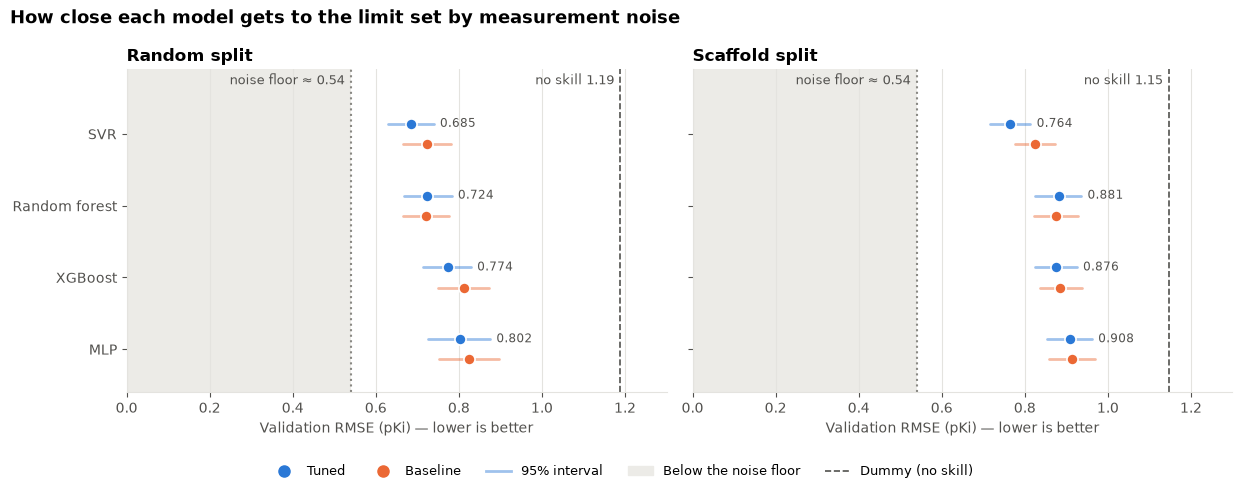

In [3]:
INK_SECONDARY, GRID, SHADE = "#52514e", "#e4e3df", "#ecebe7"
BLUE, ORANGE, NEUTRAL = "#2a78d6", "#eb6834", "#8a8984"   # Colorblind-safe reference palette.
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.edgecolor": GRID,
                     "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
                     "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})
families = {"Support vector regression": "SVR", "Random forest": "Random forest", "XGBoost": "XGBoost", "Multilayer perceptron": "MLP"}
# Rank rows by the tuned models on the random split; both panels use the same order.
order = (scores[(scores["variant"] == "tuned") & (scores["split_strategy"] == "random") & scores["model"].isin(families)]
         .sort_values("rmse_pki")["model"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True, sharey=True)
for ax, split in zip(axes, ["random", "scaffold"]):
    ax.axvspan(0, NOISE_FLOOR, color=SHADE, linewidth=0, zorder=0)
    ax.axvline(NOISE_FLOOR, color=NEUTRAL, linestyle=":", linewidth=1.5)
    ax.axvline(no_skill[split], color=INK_SECONDARY, linestyle="--", linewidth=1.2)
    ax.text(NOISE_FLOOR - 0.015, len(order) - 0.35, f"noise floor ≈ {NOISE_FLOOR:.2f}", ha="right", va="bottom", color=INK_SECONDARY, fontsize=9)
    ax.text(no_skill[split] - 0.015, len(order) - 0.35, f"no skill {no_skill[split]:.2f}", ha="right", va="bottom", color=INK_SECONDARY, fontsize=9)
    for position, model in enumerate(order):
        for variant, color, offset in [("tuned", BLUE, 0.14), ("baseline", ORANGE, -0.14)]:
            row = scores[(scores["model"] == model) & (scores["variant"] == variant) & (scores["split_strategy"] == split)].iloc[0]
            y = len(order) - 1 - position + offset
            ax.plot([row.rmse_low, row.rmse_high], [y, y], color=color, linewidth=2, alpha=0.45, solid_capstyle="round")
            ax.scatter(row.rmse_pki, y, s=64, color=color, edgecolor="white", linewidth=1.2, zorder=3)
            if variant == "tuned":
                ax.text(row.rmse_high + 0.015, y, f"{row.rmse_pki:.3f}", va="center", fontsize=8.5, color=INK_SECONDARY)
    ax.set_title(f"{split.title()} split", loc="left")
    ax.set_xlabel("Validation RMSE (pKi) — lower is better")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
axes[0].set_yticks(range(len(order)), [families[m] for m in reversed(order)])
axes[0].set_ylim(-0.6, len(order) - 0.1)
axes[0].set_xlim(0, round(float(no_skill.max()) + 0.15, 1))
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig.legend(handles=[Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=8, label="Tuned"),
                    Line2D([], [], marker="o", linestyle="", color=ORANGE, markersize=8, label="Baseline"),
                    Line2D([], [], color=BLUE, linewidth=2, alpha=0.45, label="95% interval"),
                    Patch(color=SHADE, label="Below the noise floor"),
                    Line2D([], [], color=INK_SECONDARY, linestyle="--", linewidth=1.2, label="Dummy (no skill)")],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle("How close each model gets to the limit set by measurement noise", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(project_root / "results/noise_ceiling.png", dpi=200, bbox_inches="tight", metadata={"Software": None})
plt.show()

## Summary

The table and statements below are generated from the numbers above. "Share of achievable" is how far a model got from no skill (0%) toward the noise floor (100%).

In [4]:
print(f"{'Model / variant':<38} | {'Split':<8} | {'RMSE':>6} | {'95% interval':>13} | {'Share of achievable':>19}")
for _, row in scores[scores["model"].isin(families)].sort_values(["split_strategy", "rmse_pki"]).iterrows():
    print(f"{row.model + ' / ' + row.variant:<38} | {row.split_strategy:<8} | {row.rmse_pki:>6.3f} | "
          f"{row.rmse_low:.3f} - {row.rmse_high:.3f} | {row.share_of_achievable:>19.0%}")
print()
for split in ["random", "scaffold"]:
    tuned = scores[(scores["split_strategy"] == split) & (scores["variant"] == "tuned") & scores["model"].isin(families)]
    best = tuned.loc[tuned["rmse_pki"].idxmin()]
    # A rival is "not distinguishable" if the resampled RMSE difference can be zero or negative.
    tied = [row.model for index, row in tuned.drop(best.name).iterrows() if np.percentile(samples[index] - samples[best.name], 2.5) <= 0]
    print(f"{split.upper()}: best model {best.model}, RMSE {best.rmse_pki:.3f} (95% interval {best.rmse_low:.3f}-{best.rmse_high:.3f}), "
          f"against a dummy at {no_skill[split]:.3f} and a noise floor of about {NOISE_FLOOR:.2f}. It covers {best.share_of_achievable:.0%} of "
          f"the distance from no skill to the floor; {best.rmse_pki - NOISE_FLOOR:.2f} pKi of RMSE remains above the floor. "
          + (f"Not distinguishable from: {', '.join(tied)}." if tied else "Its lead over the other tuned models exceeds the sampling uncertainty."))
    print()
print(f"CAVEATS: the {NOISE_FLOOR:.2f} floor is a ChEMBL-wide published average, not measured for CB2. As a check, the 1 pKi rule "
      f"removed {repeats['removed'].sum()} of {len(repeats)} molecules measured in different assays, versus about {expected_at_floor:.0f} "
      f"expected by chance at that noise level. Validation labels were inspected during development, so these are development "
      f"estimates; the reserved test sets are still unevaluated.")

Model / variant                        | Split    |   RMSE |  95% interval | Share of achievable
Support vector regression / tuned      | random   |  0.685 | 0.631 - 0.740 |                 78%
Random forest / baseline               | random   |  0.721 | 0.667 - 0.775 |                 72%
Support vector regression / baseline   | random   |  0.724 | 0.666 - 0.780 |                 72%
Random forest / tuned                  | random   |  0.724 | 0.667 - 0.783 |                 72%
XGBoost / tuned                        | random   |  0.774 | 0.714 - 0.829 |                 64%
Multilayer perceptron / tuned          | random   |  0.802 | 0.725 - 0.875 |                 60%
XGBoost / baseline                     | random   |  0.813 | 0.750 - 0.874 |                 58%
Multilayer perceptron / baseline       | random   |  0.825 | 0.752 - 0.896 |                 56%
Support vector regression / tuned      | scaffold |  0.764 | 0.717 - 0.814 |                 63%
Support vector regression / ba